In [1]:
from  langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores  import FAISS
from langchain_core.messages import HumanMessage
from langchain_text_splitters import sentence_transformers


C:\Users\PC\AppData\Local\Temp\ipykernel_12088\1999857098.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\PC\AppData\Local\Temp\ipykernel_12088\3721004908.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.text_splitter import SemanticChunker


In [3]:
docs=PyPDFLoader(r"C:\Users\PC\Downloads\Designing_Scalable_Agentic_AI_Platforms.pdf").load()
print(len(docs))

9


In [4]:
# chunks of docs
chunks=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=20).split_documents(documents=docs)

In [5]:
print((len(chunks)))

584


In [6]:
# embeddding
#embeding=HuggingFaceEmbeddings(model_name='all-miniLm-L6-v2')
embediing=HuggingFaceEmbeddings(model_name='all-miniLm-L6-v2')

C:\Users\PC\AppData\Local\Temp\ipykernel_12088\423650519.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embediing=HuggingFaceEmbeddings(model_name='all-miniLm-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
vectorestore=FAISS.from_documents(documents=chunks,embedding=embediing)

In [8]:
reatriver=vectorestore.as_retriever(
    serch_type='similarity',serch_kwarg={'k':4}
)


In [9]:
llm=ChatOllama(model='qwen2.5:3b')

In [10]:
# now build a workflow that start to retriver to genrate anser to end
from  typing import TypedDict
from langchain_core.documents import Document
class chatestate(TypedDict):
    question:str
    docss:list[Document]
    
    answer:str


In [11]:
# build retriver node
def retriverok(state:chatestate):
    
    question=state['question']
    response=reatriver.invoke(question)
    return {'docss':response}


In [ ]:
from langchain_classic.tools import tool

def genrate_ans(state:chatestate):
    
    question=state['question']
    context=''.join(d.page_content for d in state['docss'])
    prompt=f'give answer only from context- {context}  of question- {question} if not say  i  not know'
    response=llm.invoke(prompt)
    return {'answer':response}

In [34]:
grapg=StateGraph(chatestate)

In [35]:
grapg.add_node('retriver',retriverok)
grapg.add_node('genrate_ans',genrate_ans)
grapg.add_edge(START,'retriver')
grapg.add_edge('retriver','genrate_ans')
grapg.add_edge('genrate_ans',END)
chatbot=grapg.compile()

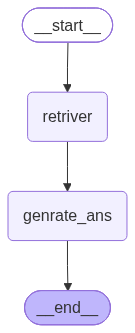

In [36]:
chatbot

In [64]:
user={'question':'email?','docss':[],'answer':''}
ans=chatbot.invoke(user)
for i in range(3):
    print(ans['docss'][i].page_content)
    print('*'*20)


Email: mukerjeejoy@protonmail.com
Abstract—The orchestration of large language models (LLMs)
********************
message passing, blackboard systems).
********************
with telemetry systems (e.g., Google Cloud Monitoring,
********************


In [ ]:

for i in range(3):
    print(ans['docss'][i].page_content)
    print('*'*20)




Joy Mukerjee
AI Platform Research Lead
Enterprise Systems, Independent Researcher
********************
Sons, 2009.
[5] Z. Liu, L. Chilton, E. Zhang, D. Kiela, and A. Bosselut, “G-
********************
Designing Scalable Agentic AI Platforms for
Enterprise LLM Orchestration
Joy Mukerjee
********************


In [18]:
from langchain_classic.tools import tool
@tool
def from_docs(query:str):
    """Retrieve relevant documents and combine their contents into context"""
    do=reatriver.invoke(query)
    contex=' '.join(d.page_content for d in do)
    prompt=f'answer only from contex -{contex} of query-{query}'
    result=llm.invoke(prompt)
    return result




In [55]:
result = from_docs.invoke({"query": "my name is ravi"})

In [56]:
print(result.content)

The text "You are an enterprise-of query-my name is ravi" seems to be a partial or incomplete message. Without more context, it's difficult to determine the full intent or purpose behind this part of the communication. It appears to start with an introduction and then introduces the sender's self-introduction as "ravi". 

If you're looking for information on how AI assistants like Qwen can be integrated into enterprise systems, I can provide more detailed insights based on my training data related to AI platform research and cloud services.
